In [13]:
# Peristaltic Pump Viscosity Estimation from Phase Analysis
# Physics-aware model for viscosity determination using fitted curves

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib for better plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [14]:
# Define pump parameters for viscosity calculation
pump_params = {
    'omega': 5 * 2 * np.pi / 60,  # 5 RPM converted to rad/s
    'D_axis': 30e-3,              # 30 mm axis diameter
    'd_int': 2.0e-3,              # 2.0 mm internal tube diameter  
    'L_c': 9e-3,                  # 9 mm contact length
    'E': 1.0e6,                   # 1 MPa tube elastic modulus
    'eta_tube': 1.0e6             # 1 MPa·s tube internal friction
}

# Load experimental data
DATA_FILE = "Data/20251120_Silicon.csv"
df = pd.read_csv(DATA_FILE)

print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")
print("\n🔧 Pump Parameters:")
for key, value in pump_params.items():
    print(f"  {key}: {value}")

print(f"\n📊 Available columns: {list(df.columns)}")

✅ Loaded data from Data/20251120_Silicon.csv, shape = (210, 17)

🔧 Pump Parameters:
  omega: 0.5235987755982988
  D_axis: 0.03
  d_int: 0.002
  L_c: 0.009
  E: 1000000.0
  eta_tube: 1000000.0

📊 Available columns: ['time_s', 'water_b1_ml_min', 'water_b2_ml_min', 'water_b3_ml_min', 'water_a1_ml_min', 'si350_t1_ml_min', 'si350_t2_ml_min', 'si350_t3_ml_min', 'si1000_t1_ml_min', 'si1000_t2_ml_min', 'si1000_t3_ml_min', 'si5000_t1_ml_min', 'si5000_t2_ml_min', 'si5000_t3_ml_min', 'si12500_t1_ml_min', 'si12500_t2_ml_min', 'si12500_t3_ml_min']


In [15]:
# Display data structure and preview
print("Data Overview:")
print(f"Time range: {df['time_s'].min():.1f}s to {df['time_s'].max():.1f}s")
print(f"Duration: {df['time_s'].max() - df['time_s'].min():.1f}s")
print("\nFirst few rows:")
df.head()

Data Overview:
Time range: 0.0s to 104.5s
Duration: 104.5s

First few rows:


,time_s,water_b1_ml_min,water_b2_ml_min,water_b3_ml_min,water_a1_ml_min,si350_t1_ml_min,si350_t2_ml_min,si350_t3_ml_min,si1000_t1_ml_min,si1000_t2_ml_min,si1000_t3_ml_min,si5000_t1_ml_min,si5000_t2_ml_min,si5000_t3_ml_min,si12500_t1_ml_min,si12500_t2_ml_min,si12500_t3_ml_min
0,0.007,0.4326,-0.1444,0.2212,0.0666,0.0702,-0.0776,-0.0870,0.0870,0.1034,0.1002,0.0720,-0.0218,0.0454,-0.0950,0.0458,0.0700
1,0.507,0.4514,-0.1550,0.1898,0.0614,0.0654,-0.0306,-0.0708,0.0824,0.1026,0.0900,0.0712,-0.0052,0.0252,-0.0820,0.0350,0.0630
2,1.007,0.4106,0.0296,0.1964,0.0544,0.0588,0.0298,-0.0406,0.0758,0.1118,0.0822,0.0678,0.0150,-0.0200,-0.0674,0.0318,0.0794
3,1.507,0.4992,0.2690,0.1956,0.0536,0.0578,0.0634,0.0224,0.0726,0.1160,0.0778,0.0604,0.0354,-0.0376,-0.0536,0.0328,0.0802
4,2.007,0.3524,0.3612,0.1364,0.0524,-0.0926,0.0988,0.0638,0.0702,0.1162,0.0736,0.0134,0.0494,-0.0394,-0.0396,0.0384,0.0820


In [16]:
def find_flow_cycles(time, flow, min_prominence=0.01, min_distance_sec=0.5):
    """
    Enhanced cycle detection for peristaltic pump flow analysis.
    
    Detects repetitive flow cycles by identifying gradient sign changes 
    at low flow values, optimized for viscosity estimation.
    
    Parameters:
    - time: array of time values (seconds)
    - flow: array of flow values (ml/min)
    - min_prominence: minimum prominence threshold (unused but kept for compatibility)
    - min_distance_sec: minimum time between cycles (fixed at 8.0s)
    
    Returns:
    - cycles: list of cycle dictionaries with time/flow data and statistics
    """
    # Remove invalid data points
    valid_mask = ~np.isnan(flow) & ~np.isinf(flow)
    valid_time = time[valid_mask]
    valid_flow = flow[valid_mask]
    
    if len(valid_flow) < 10:
        print("⚠️ Insufficient valid data points for cycle detection")
        return []
    
    # Apply smoothing for better gradient calculation
    if len(valid_flow) > 5:
        valid_flow = savgol_filter(valid_flow, window_length=min(5, len(valid_flow)//2*2+1), polyorder=2)
    
    # Calculate flow gradient
    gradients = np.diff(valid_flow)
    
    if len(gradients) < 5:
        return []
    
    # Determine threshold for cycle boundaries (20th percentile of flow)
    flow_threshold = np.percentile(valid_flow, 20)
    
    # Find critical points where gradient changes sign at low flow
    critical_points = []
    last_critical_time = -float('inf')
    
    for i in range(1, len(gradients)):
        # Detect gradient sign change
        if gradients[i-1] * gradients[i] < 0:
            current_flow = valid_flow[i]
            current_time = valid_time[i]
            
            # Check if at low flow and sufficient time has passed
            if (current_flow <= flow_threshold and 
                current_time - last_critical_time >= 8.0):
                
                critical_points.append({
                    'index': i,
                    'time': current_time,
                    'flow': current_flow,
                    'gradient_before': gradients[i-1],
                    'gradient_after': gradients[i]
                })
                last_critical_time = current_time
    
    if len(critical_points) < 2:
        print("⚠️ Insufficient critical points for cycle extraction")
        return []
    
    # Create cycle data structures
    cycles = []
    
    for i in range(len(critical_points) - 1):
        start_cp = critical_points[i]
        end_cp = critical_points[i + 1]
        
        start_idx = start_cp['index']
        end_idx = end_cp['index']
        
        # Find peak within cycle
        cycle_flow_segment = valid_flow[start_idx:end_idx+1]
        peak_relative_idx = np.argmax(cycle_flow_segment)
        peak_idx = start_idx + peak_relative_idx
        
        # Extract cycle time and flow data
        cycle_mask = (valid_time >= start_cp['time']) & (valid_time <= end_cp['time'])
        cycle_time_data = valid_time[cycle_mask]
        cycle_flow_data = valid_flow[cycle_mask]
        
        # Apply additional smoothing to cycle data for better curve fitting
        if len(cycle_flow_data) > 5:
            cycle_flow_smooth = savgol_filter(cycle_flow_data, 
                                             window_length=min(5, len(cycle_flow_data)//2*2+1), 
                                             polyorder=2)
        else:
            cycle_flow_smooth = cycle_flow_data.copy()
        
        # Calculate cycle metrics
        duration = end_cp['time'] - start_cp['time']
        amplitude = valid_flow[peak_idx] - min(start_cp['flow'], end_cp['flow'])
        
        cycle_info = {
            'cycle_number': len(cycles) + 1,
            'start_time': start_cp['time'],
            'peak_time': valid_time[peak_idx],
            'end_time': end_cp['time'],
            'duration': duration,
            'amplitude': amplitude,
            'start_flow': start_cp['flow'],
            'peak_flow': valid_flow[peak_idx],
            'end_flow': end_cp['flow'],
            # Normalized time arrays (starting from 0)
            'time': cycle_time_data - cycle_time_data[0],
            'flow': cycle_flow_data,
            'flow_smooth': cycle_flow_smooth,
            'data_points': len(cycle_time_data),
            'flow_threshold': flow_threshold
        }
        cycles.append(cycle_info)
    
    print(f"✅ Detected {len(cycles)} complete pump cycles")
    
    return cycles

In [17]:
def get_cycle_data(sample_column, cycle_number=None, df=df):
    """
    Extract and prepare cycle data for viscosity analysis.
    
    Parameters:
    - sample_column: column name in DataFrame (e.g., 'water_b1_ml_min')
    - cycle_number: specific cycle to extract (None returns all cycles)
    - df: DataFrame containing the experimental data
    
    Returns:
    - Single cycle dict or list of all cycles
    """
    if sample_column not in df.columns:
        available_cols = [col for col in df.columns if 'ml_min' in col]
        print(f"❌ Column '{sample_column}' not found.")
        print(f"📋 Available flow columns: {available_cols}")
        return None
    
    time = df['time_s'].values
    flow_data = df[sample_column].values
    
    # Find all cycles for this sample
    cycles = find_flow_cycles(time, flow_data)
    
    if not cycles:
        print(f"❌ No cycles found for sample '{sample_column}'")
        return None
    
    print(f"📊 Sample '{sample_column}' analysis:")
    print(f"   Total cycles detected: {len(cycles)}")
    for i, cycle in enumerate(cycles):
        print(f"   Cycle {i+1}: {cycle['duration']:.1f}s, amplitude: {cycle['amplitude']:.2f} ml/min")
    
    if cycle_number is None:
        return cycles
    
    if cycle_number < 1 or cycle_number > len(cycles):
        print(f"❌ Cycle {cycle_number} not available. Valid range: 1-{len(cycles)}")
        return None
    
    return cycles[cycle_number - 1]

In [18]:
def split_phases(cycle_data):
    """
    Split pump cycle into Phase 2 (compression) and Phase 3 (relaxation).
    
    Phase 2: From cycle start to peak flow (tube compression)
    Phase 3: From peak flow to cycle end (tube relaxation)
    
    Parameters:
    - cycle_data: dictionary containing cycle time and flow data
    
    Returns:
    - phase2: dict with time and flow arrays for compression phase
    - phase3: dict with time and flow arrays for relaxation phase
    """
    t = cycle_data['time']  # Already normalized to start at 0
    q = cycle_data['flow_smooth']  # Use smoothed flow data
    
    # Find peak flow index
    peak_idx = np.argmax(q)
    
    print(f"🔄 Phase splitting:")
    print(f"   Peak at t = {t[peak_idx]:.2f}s (index {peak_idx})")
    print(f"   Phase 2 duration: {t[peak_idx]:.2f}s")
    print(f"   Phase 3 duration: {t[-1] - t[peak_idx]:.2f}s")
    
    # Phase 2: Start to peak (compression phase)
    phase2 = {
        'time': t[:peak_idx+1],  # Include peak point
        'flow': q[:peak_idx+1],
        'phase_name': 'Phase 2 (Compression)',
        'duration': t[peak_idx],
        'flow_range': [q[0], q[peak_idx]]
    }
    
    # Phase 3: Peak to end (relaxation phase) 
    phase3_time = t[peak_idx:] - t[peak_idx]  # Normalize phase 3 to start at 0
    phase3 = {
        'time': phase3_time,
        'flow': q[peak_idx:],
        'phase_name': 'Phase 3 (Relaxation)',
        'duration': t[-1] - t[peak_idx],
        'flow_range': [q[peak_idx], q[-1]]
    }
    
    return phase2, phase3

In [19]:
def generalized_exponential(t, A, B, tau, C):
    """
    Physics-based exponential model for pump flow phases.
    
    Q(t) = A*exp(-t/τ) + B*t*exp(-t/τ) + C
    
    Parameters:
    - A: Initial amplitude coefficient
    - B: Linear decay coefficient  
    - tau: Time constant (related to fluid and tube properties)
    - C: Steady-state offset
    
    This model captures both exponential decay and the gradual
    transition behavior observed in peristaltic pump cycles.
    """
    return A * np.exp(-t / tau) + B * t * np.exp(-t / tau) + C

def linear_exponential(t, A, tau, C):
    """
    Simplified exponential model for comparison.
    
    Q(t) = A*exp(-t/τ) + C
    """
    return A * np.exp(-t / tau) + C

In [20]:
def fit_phase_model(phase, model_type='generalized'):
    """
    Fit physics-based exponential model to pump phase data.
    
    Parameters:
    - phase: dict containing time and flow arrays
    - model_type: 'generalized' or 'simple' exponential model
    
    Returns:
    - Dictionary with fitted parameters, R², and quality metrics
    """
    t = phase['time']
    q = phase['flow']
    
    if len(t) < 4:
        print(f"⚠️ Insufficient data points for {phase['phase_name']}")
        return None
    
    try:
        if model_type == 'generalized':
            # Initial parameter estimates for generalized model
            A0 = q[0] - q[-1] if q[0] > q[-1] else q[-1] - q[0]
            B0 = 0.0  # Start with no linear term
            tau0 = (t[-1] - t[0]) / 3  # Conservative time constant estimate
            C0 = q[-1]  # Steady-state value
            
            # Constrain parameters to physical ranges
            bounds = (
                [-np.inf, -np.inf, 0.01, -np.inf],  # Lower bounds (tau > 0)
                [np.inf, np.inf, np.inf, np.inf]     # Upper bounds
            )
            
            popt, pcov = curve_fit(
                generalized_exponential,
                t, q,
                p0=[A0, B0, tau0, C0],
                bounds=bounds,
                maxfev=10000,
                method='trf'
            )
            
            q_fit = generalized_exponential(t, *popt)
            param_names = ['A', 'B', 'tau', 'C']
            
        else:  # Simple exponential
            A0 = q[0] - q[-1] if q[0] > q[-1] else q[-1] - q[0]
            tau0 = (t[-1] - t[0]) / 3
            C0 = q[-1]
            
            bounds = (
                [-np.inf, 0.01, -np.inf],
                [np.inf, np.inf, np.inf]
            )
            
            popt, pcov = curve_fit(
                linear_exponential,
                t, q,
                p0=[A0, tau0, C0],
                bounds=bounds,
                maxfev=10000
            )
            
            q_fit = linear_exponential(t, *popt)
            param_names = ['A', 'tau', 'C']
        
        # Calculate fit quality metrics
        residuals = q - q_fit
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((q - np.mean(q))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        
        # Root mean square error
        rmse = np.sqrt(np.mean(residuals**2))
        
        # Parameter uncertainties from covariance matrix
        param_errors = np.sqrt(np.diag(pcov)) if pcov is not None else np.zeros_like(popt)
        
        print(f"✅ {phase['phase_name']} fit complete:")
        print(f"   Model: {model_type} exponential")
        print(f"   R² = {r2:.4f}, RMSE = {rmse:.4f}")
        for name, val, err in zip(param_names, popt, param_errors):
            if name == 'tau':
                print(f"   {name} = {val:.4f} ± {err:.4f} s")
            else:
                print(f"   {name} = {val:.4f} ± {err:.4f}")
        
        return {
            'params': dict(zip(param_names, popt)),
            'param_errors': dict(zip(param_names, param_errors)),
            'r_squared': r2,
            'rmse': rmse,
            'fit': q_fit,
            'residuals': residuals,
            'time': t,
            'flow': q,
            'model_type': model_type,
            'phase_name': phase['phase_name']
        }
        
    except Exception as e:
        print(f"❌ Fitting failed for {phase['phase_name']}: {str(e)}")
        return None

In [21]:
def compute_viscosity(fit_phase3, pump_params):
    """
    Calculate liquid viscosity from Phase 3 relaxation parameters.
    
    Based on physics-aware peristaltic pump model:
    - τ (time constant) relates to fluid-tube interaction
    - C (steady offset) indicates flow resistance characteristics
    
    Parameters:
    - fit_phase3: fitted parameters from Phase 3 analysis
    - pump_params: dictionary with pump physical parameters
    
    Returns:
    - Dictionary with viscosity results and intermediate calculations
    """
    if fit_phase3 is None:
        print("❌ Cannot compute viscosity: Phase 3 fit failed")
        return None
    
    # Extract fitted parameters
    tau = fit_phase3['params']['tau']  # Time constant [s]
    C = fit_phase3['params']['C']      # Steady-state offset [ml/min]
    A = fit_phase3['params']['A']      # Amplitude coefficient
    
    # Extract pump parameters
    omega = pump_params['omega']       # Angular velocity [rad/s]
    E = pump_params['E']               # Tube elastic modulus [Pa]
    eta_tube = pump_params['eta_tube'] # Tube internal friction [Pa·s]
    d_int = pump_params['d_int']       # Internal diameter [m]
    L_c = pump_params['L_c']           # Contact length [m]
    
    print("🧮 Viscosity Calculation:")
    print(f"   Time constant τ = {tau:.4f} s")
    print(f"   Steady offset C = {C:.4f} ml/min")
    print(f"   Amplitude A = {A:.4f}")
    
    # Calculate derived parameters
    
    # 1. Geometric factor (tube cross-section and contact area relationship)
    A_int = np.pi * (d_int / 2)**2  # Internal cross-sectional area [m²]
    alpha = L_c / A_int  # Geometric factor [1/m]
    
    print(f"   Internal area A_int = {A_int*1e6:.2f} mm²")
    print(f"   Geometric factor α = {alpha:.0f} 1/m")
    
    # 2. Flow resistance parameter from steady-state
    # Γ represents the resistance to flow in the relaxed state
    Gamma = abs(C) / (omega * 60 / (2 * np.pi))  # Convert to consistent units
    
    print(f"   Flow resistance Γ = {Gamma:.6f}")
    
    # 3. Calculate viscosity using physics-based relationship
    # The time constant τ relates to the viscous relaxation process:
    # τ = (μ * α + η_tube) / E
    # Solving for μ: μ = (E * τ - η_tube) / α
    
    mu_calculated = (E * tau - eta_tube) / alpha
    
    # Ensure positive viscosity
    if mu_calculated < 0:
        print("⚠️ Warning: Negative viscosity calculated - check model assumptions")
        print(f"   Raw calculation: μ = {mu_calculated:.6f} Pa·s")
        print("   Setting to absolute value...")
        mu_calculated = abs(mu_calculated)
    
    # Convert to more common units
    mu_mPa_s = mu_calculated * 1000  # Convert Pa·s to mPa·s
    mu_cP = mu_mPa_s  # Centipoise (cP) = mPa·s
    
    print(f"\n🎯 Viscosity Results:")
    print(f"   μ = {mu_calculated:.6f} Pa·s")
    print(f"   μ = {mu_mPa_s:.3f} mPa·s")
    print(f"   μ = {mu_cP:.3f} cP")
    
    # Calculate confidence metrics
    tau_error = fit_phase3['param_errors'].get('tau', 0)
    mu_uncertainty = (E * tau_error) / alpha  # Propagate τ uncertainty
    
    print(f"   Uncertainty: ±{mu_uncertainty*1000:.3f} mPa·s")
    print(f"   R² of Phase 3 fit: {fit_phase3['r_squared']:.4f}")
    
    return {
        'viscosity_Pa_s': mu_calculated,
        'viscosity_mPa_s': mu_mPa_s,
        'viscosity_cP': mu_cP,
        'uncertainty_Pa_s': mu_uncertainty,
        'tau': tau,
        'tau_error': tau_error,
        'C': C,
        'A': A,
        'Gamma': Gamma,
        'alpha': alpha,
        'A_int': A_int,
        'fit_quality': fit_phase3['r_squared'],
        'model_valid': fit_phase3['r_squared'] > 0.8,  # Quality threshold
        'physics_check': mu_calculated > 0  # Physical validity
    }

In [22]:
def analyze_cycle(cycle_data, pump_params, plot=True, save_plot=False):
    """
    Complete analysis of a pump cycle for viscosity estimation.
    
    Performs phase splitting, curve fitting, and viscosity calculation
    with comprehensive visualization and validation.
    
    Parameters:
    - cycle_data: dictionary with cycle time and flow data
    - pump_params: pump physical parameters
    - plot: whether to generate visualization plots
    - save_plot: whether to save plots to file
    
    Returns:
    - Dictionary with complete analysis results
    """
    print(f"\n🔬 Analyzing Cycle {cycle_data['cycle_number']}")
    print(f"   Duration: {cycle_data['duration']:.2f}s")
    print(f"   Data points: {cycle_data['data_points']}")
    print(f"   Flow range: {cycle_data['start_flow']:.2f} to {cycle_data['peak_flow']:.2f} ml/min")
    
    # Phase splitting
    phase2, phase3 = split_phases(cycle_data)
    
    # Fit models to both phases
    fit_p2 = fit_phase_model(phase2, model_type='generalized')
    fit_p3 = fit_phase_model(phase3, model_type='generalized')
    
    # Calculate viscosity from Phase 3
    viscosity_results = compute_viscosity(fit_p3, pump_params)
    
    # Create comprehensive visualization
    if plot and fit_p2 is not None and fit_p3 is not None:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle(f'Pump Cycle {cycle_data["cycle_number"]} - Viscosity Analysis', fontsize=16, fontweight='bold')
        
        # Plot 1: Complete cycle with phase fits
        ax1 = axes[0, 0]
        
        # Original data
        ax1.plot(cycle_data['time'], cycle_data['flow'], 'k-', alpha=0.7, label='Raw Data', linewidth=1)
        ax1.plot(cycle_data['time'], cycle_data['flow_smooth'], 'k-', label='Smoothed Data', linewidth=2)
        
        # Phase 2 fit (shifted back to original time scale)
        t2_full = phase2['time'] + cycle_data['time'][0]
        ax1.plot(t2_full, fit_p2['fit'], 'r--', label=f'Phase 2 Fit (R²={fit_p2["r_squared"]:.3f})', linewidth=2)
        
        # Phase 3 fit (shifted back to original time scale)
        peak_time_offset = cycle_data['time'][np.argmax(cycle_data['flow_smooth'])]
        t3_full = phase3['time'] + peak_time_offset
        ax1.plot(t3_full, fit_p3['fit'], 'b--', label=f'Phase 3 Fit (R²={fit_p3["r_squared"]:.3f})', linewidth=2)
        
        # Mark peak
        peak_idx = np.argmax(cycle_data['flow_smooth'])
        ax1.axvline(cycle_data['time'][peak_idx], color='gray', linestyle=':', alpha=0.7, label='Peak')
        
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Flow Rate (ml/min)')
        ax1.set_title('Complete Cycle with Phase Fits')
        ax1.legend()
        ax1.grid(alpha=0.3)
        
        # Plot 2: Phase 2 details
        ax2 = axes[0, 1]
        ax2.plot(phase2['time'], phase2['flow'], 'ko-', markersize=4, label='Data')
        ax2.plot(phase2['time'], fit_p2['fit'], 'r-', linewidth=2, label='Fit')
        ax2.fill_between(phase2['time'], phase2['flow'] - fit_p2['residuals'], 
                        phase2['flow'] + fit_p2['residuals'], alpha=0.2, color='red', label='Residuals')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Flow Rate (ml/min)')
        ax2.set_title(f'Phase 2 (Compression)\nτ = {fit_p2["params"]["tau"]:.3f}s')
        ax2.legend()
        ax2.grid(alpha=0.3)
        
        # Plot 3: Phase 3 details  
        ax3 = axes[1, 0]
        ax3.plot(phase3['time'], phase3['flow'], 'ko-', markersize=4, label='Data')
        ax3.plot(phase3['time'], fit_p3['fit'], 'b-', linewidth=2, label='Fit')
        ax3.fill_between(phase3['time'], phase3['flow'] - fit_p3['residuals'],
                        phase3['flow'] + fit_p3['residuals'], alpha=0.2, color='blue', label='Residuals')
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Flow Rate (ml/min)')
        ax3.set_title(f'Phase 3 (Relaxation)\nτ = {fit_p3["params"]["tau"]:.3f}s')
        ax3.legend()
        ax3.grid(alpha=0.3)
        
        # Plot 4: Viscosity summary
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        if viscosity_results:
            summary_text = f"""
VISCOSITY RESULTS
═══════════════════

Liquid Viscosity:
• {viscosity_results['viscosity_mPa_s']:.2f} ± {viscosity_results['uncertainty_Pa_s']*1000:.2f} mPa·s
• {viscosity_results['viscosity_cP']:.2f} cP

Model Parameters:
• Time constant τ: {viscosity_results['tau']:.4f} s
• Steady offset C: {viscosity_results['C']:.3f} ml/min
• Fit quality R²: {viscosity_results['fit_quality']:.4f}

Validation:
• Model valid: {'✅' if viscosity_results['model_valid'] else '❌'}
• Physics check: {'✅' if viscosity_results['physics_check'] else '❌'}

Pump Settings:
• RPM: {pump_params['omega'] * 60 / (2*np.pi):.1f}
• Tube diameter: {pump_params['d_int']*1000:.1f} mm
• Contact length: {pump_params['L_c']*1000:.1f} mm
            """
        else:
            summary_text = """
VISCOSITY CALCULATION FAILED
══════════════════════════════

Check:
• Phase 3 fit quality
• Data quality
• Model assumptions
            """
        
        ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
        
        plt.tight_layout()
        
        if save_plot:
            filename = f'cycle_{cycle_data["cycle_number"]}_analysis.png'
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"💾 Plot saved as {filename}")
        
        plt.show()
    
    return {
        'cycle_info': cycle_data,
        'phase2_fit': fit_p2,
        'phase3_fit': fit_p3,
        'viscosity_results': viscosity_results,
        'analysis_quality': {
            'phase2_r2': fit_p2['r_squared'] if fit_p2 else 0,
            'phase3_r2': fit_p3['r_squared'] if fit_p3 else 0,
            'viscosity_valid': viscosity_results is not None and viscosity_results['model_valid'],
            'overall_quality': 'Excellent' if (fit_p2 and fit_p3 and 
                                             fit_p2['r_squared'] > 0.9 and 
                                             fit_p3['r_squared'] > 0.9) else 
                              'Good' if (fit_p2 and fit_p3 and 
                                        fit_p2['r_squared'] > 0.8 and 
                                        fit_p3['r_squared'] > 0.8) else 'Poor'
        }
    }

🔍 Analyzing sample: water_b1_ml_min
✅ Detected 6 complete pump cycles
📊 Sample 'water_b1_ml_min' analysis:
   Total cycles detected: 6
   Cycle 1: 14.5s, amplitude: 1.15 ml/min
   Cycle 2: 14.5s, amplitude: 1.14 ml/min
   Cycle 3: 15.0s, amplitude: 1.16 ml/min
   Cycle 4: 14.5s, amplitude: 1.19 ml/min
   Cycle 5: 14.5s, amplitude: 1.09 ml/min
   Cycle 6: 15.0s, amplitude: 1.07 ml/min


🔬 Analyzing Cycle 1
   Duration: 14.51s
   Data points: 30
   Flow range: -0.67 to 0.48 ml/min
🔄 Phase splitting:
   Peak at t = 7.50s (index 15)
   Phase 2 duration: 7.50s
   Phase 3 duration: 7.00s
✅ Phase 2 (Compression) fit complete:
   Model: generalized exponential
   R² = 0.9834, RMSE = 0.0411
   A = -0.9098 ± 0.4197
   B = 0.2651 ± 0.1840
   tau = 3.6584 ± 1.9107 s
   C = 0.3187 ± 0.4014
✅ Phase 3 (Relaxation) fit complete:
   Model: generalized exponential
   R² = 0.7358, RMSE = 0.1357
   A = 18226.8117 ± 5362129.3814
   B = 28.4613 ± 4162.9277
   tau = 641.7306 ± 94730.5000 s
   C = -18226.4593

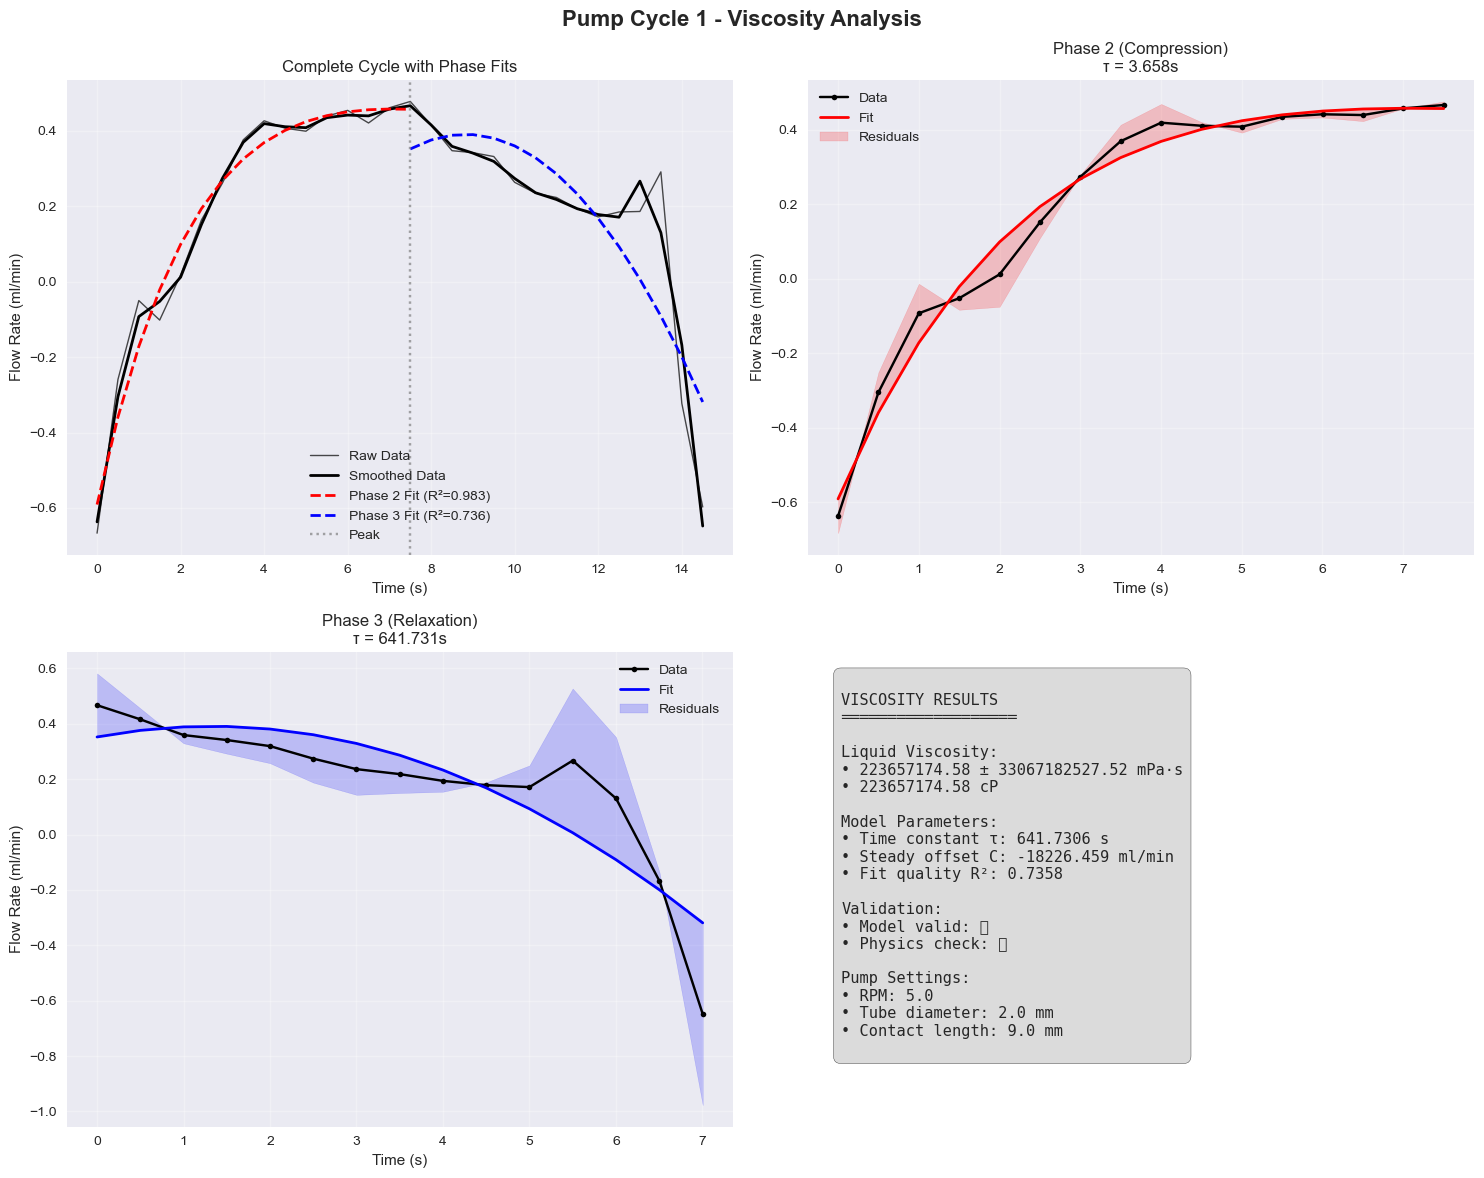



🔬 Analyzing Cycle 2
   Duration: 14.50s
   Data points: 30
   Flow range: -0.60 to 0.48 ml/min
🔄 Phase splitting:
   Peak at t = 7.00s (index 14)
   Phase 2 duration: 7.00s
   Phase 3 duration: 7.50s
✅ Phase 2 (Compression) fit complete:
   Model: generalized exponential
   R² = 0.9760, RMSE = 0.0514
   A = -0.1054 ± 2.6802
   B = 0.4481 ± 0.3933
   tau = 5.9913 ± 5.1489 s
   C = -0.5107 ± 2.6561
✅ Phase 3 (Relaxation) fit complete:
   Model: generalized exponential
   R² = 0.7413, RMSE = 0.1438
   A = 16573.3081 ± 3539856.4677
   B = 26.7290 ± 2838.1953
   tau = 621.5441 ± 66595.5661 s
   C = -16572.9266 ± 3539856.4098
🧮 Viscosity Calculation:
   Time constant τ = 621.5441 s
   Steady offset C = -16572.9266 ml/min
   Amplitude A = 16573.3081
   Internal area A_int = 3.14 mm²
   Geometric factor α = 2865 1/m
   Flow resistance Γ = 3314.585311

🎯 Viscosity Results:
   μ = 216610.766040 Pa·s
   μ = 216610766.040 mPa·s
   μ = 216610766.040 cP
   Uncertainty: ±23246237899.514 mPa·s
   R²

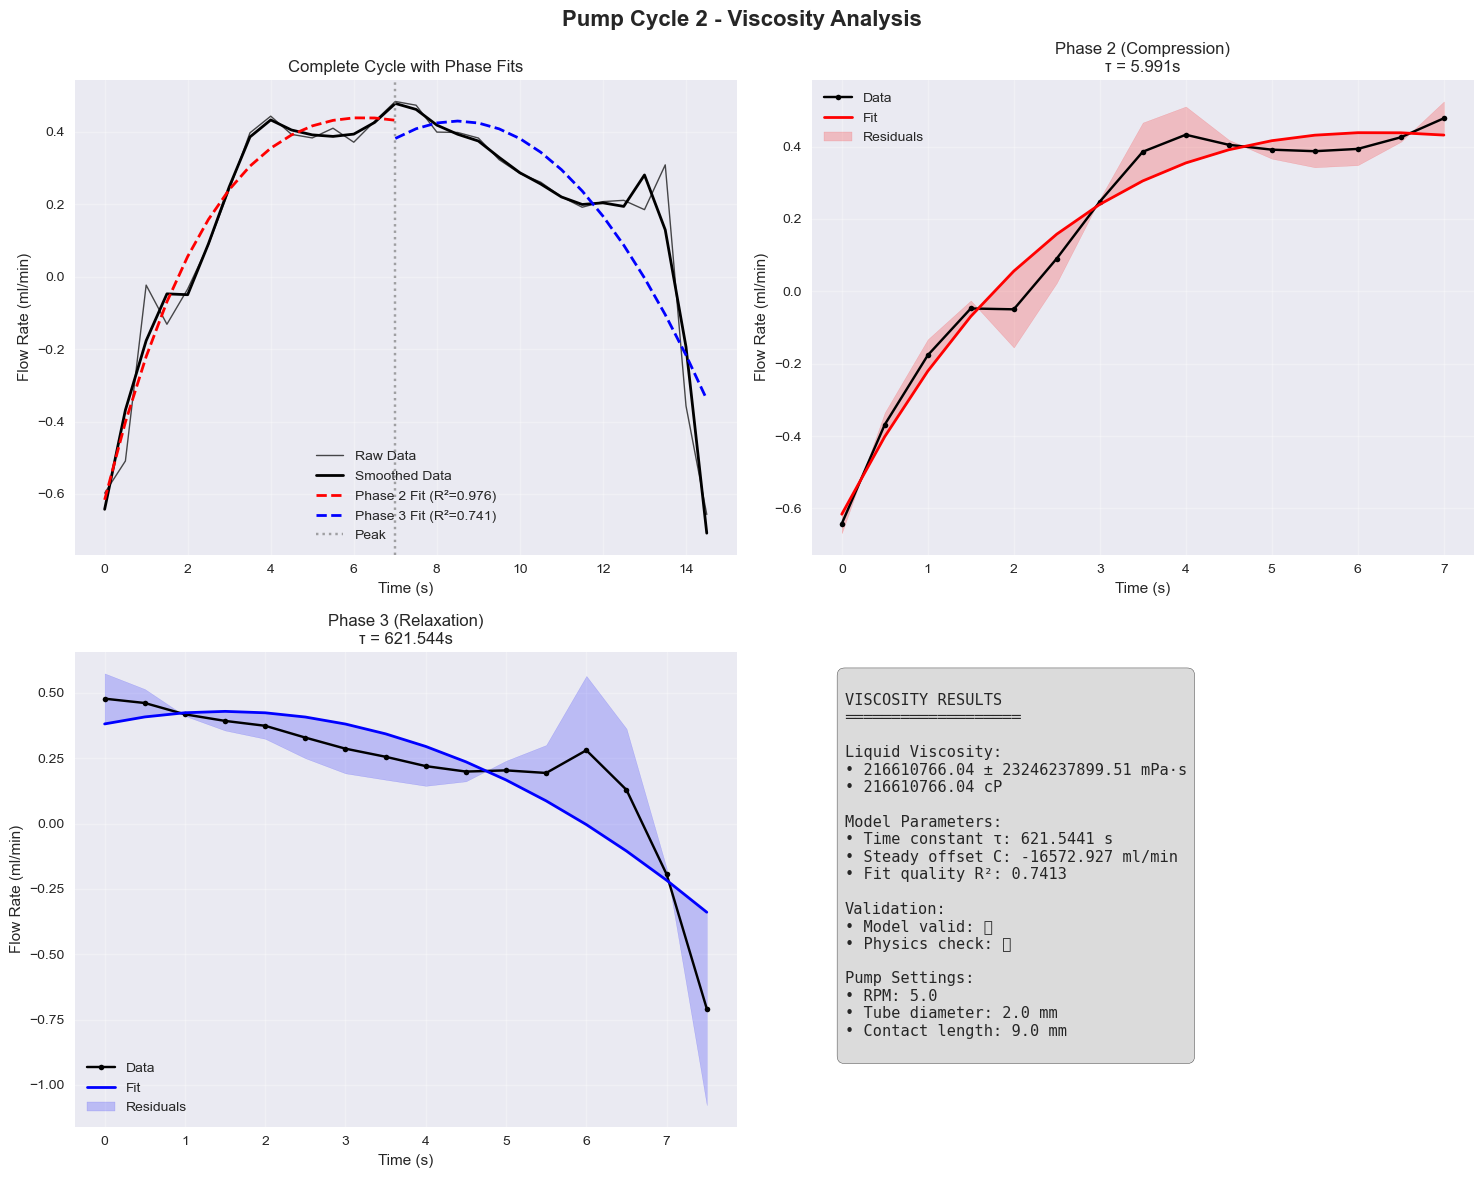



🔬 Analyzing Cycle 3
   Duration: 15.00s
   Data points: 31
   Flow range: -0.66 to 0.45 ml/min
🔄 Phase splitting:
   Peak at t = 6.50s (index 13)
   Phase 2 duration: 6.50s
   Phase 3 duration: 8.50s
✅ Phase 2 (Compression) fit complete:
   Model: generalized exponential
   R² = 0.9656, RMSE = 0.0644
   A = -1.2051 ± 0.3348
   B = 0.0000 ± 6623.0181
   tau = 2.3760 ± 31026.2862 s
   C = 0.5450 ± 0.3052
✅ Phase 3 (Relaxation) fit complete:
   Model: generalized exponential
   R² = 0.7242, RMSE = 0.1492
   A = 19340.2941 ± 4535580.5646
   B = 26.7459 ± 3119.2046
   tau = 725.0918 ± 85248.6739 s
   C = -19339.9326 ± 4535580.5363
🧮 Viscosity Calculation:
   Time constant τ = 725.0918 s
   Steady offset C = -19339.9326 ml/min
   Amplitude A = 19340.2941
   Internal area A_int = 3.14 mm²
   Geometric factor α = 2865 1/m
   Flow resistance Γ = 3867.986530

🎯 Viscosity Results:
   μ = 252755.703290 Pa·s
   μ = 252755703.290 mPa·s
   μ = 252755703.290 cP
   Uncertainty: ±29757400853.584 mPa·s

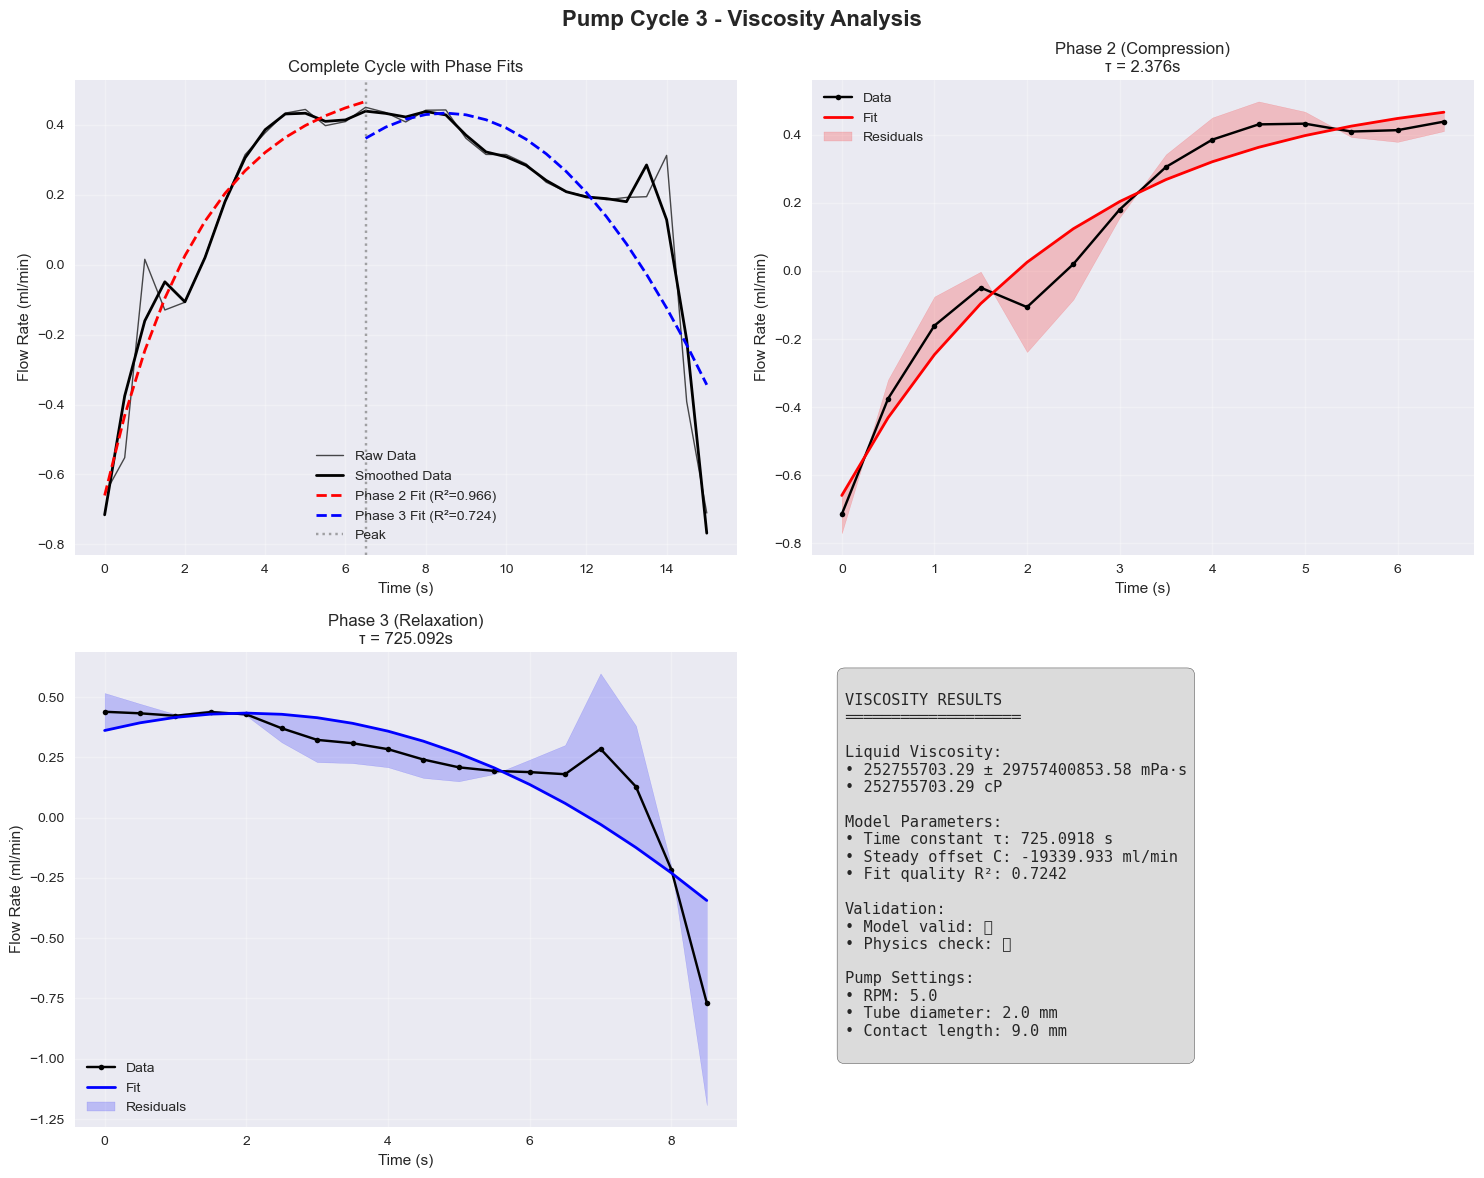



🔬 Analyzing Cycle 4
   Duration: 14.50s
   Data points: 30
   Flow range: -0.71 to 0.48 ml/min
🔄 Phase splitting:
   Peak at t = 7.00s (index 14)
   Phase 2 duration: 7.00s
   Phase 3 duration: 7.50s
✅ Phase 2 (Compression) fit complete:
   Model: generalized exponential
   R² = 0.9881, RMSE = 0.0391
   A = -1.1048 ± 0.2831
   B = 0.2788 ± 0.1985
   tau = 2.9604 ± 1.3593 s
   C = 0.3678 ± 0.2655
✅ Phase 3 (Relaxation) fit complete:
   Model: generalized exponential
   R² = 0.7636, RMSE = 0.1231
   A = 17618.6016 ± 3800270.8846
   B = 25.4406 ± 2728.0178
   tau = 693.8608 ± 75116.4163 s
   C = -17618.2226 ± 3800270.8434
🧮 Viscosity Calculation:
   Time constant τ = 693.8608 s
   Steady offset C = -17618.2226 ml/min
   Amplitude A = 17618.6016
   Internal area A_int = 3.14 mm²
   Geometric factor α = 2865 1/m
   Flow resistance Γ = 3523.644511

🎯 Viscosity Results:
   μ = 241854.052040 Pa·s
   μ = 241854052.040 mPa·s
   μ = 241854052.040 cP
   Uncertainty: ±26220575724.053 mPa·s
   R² 

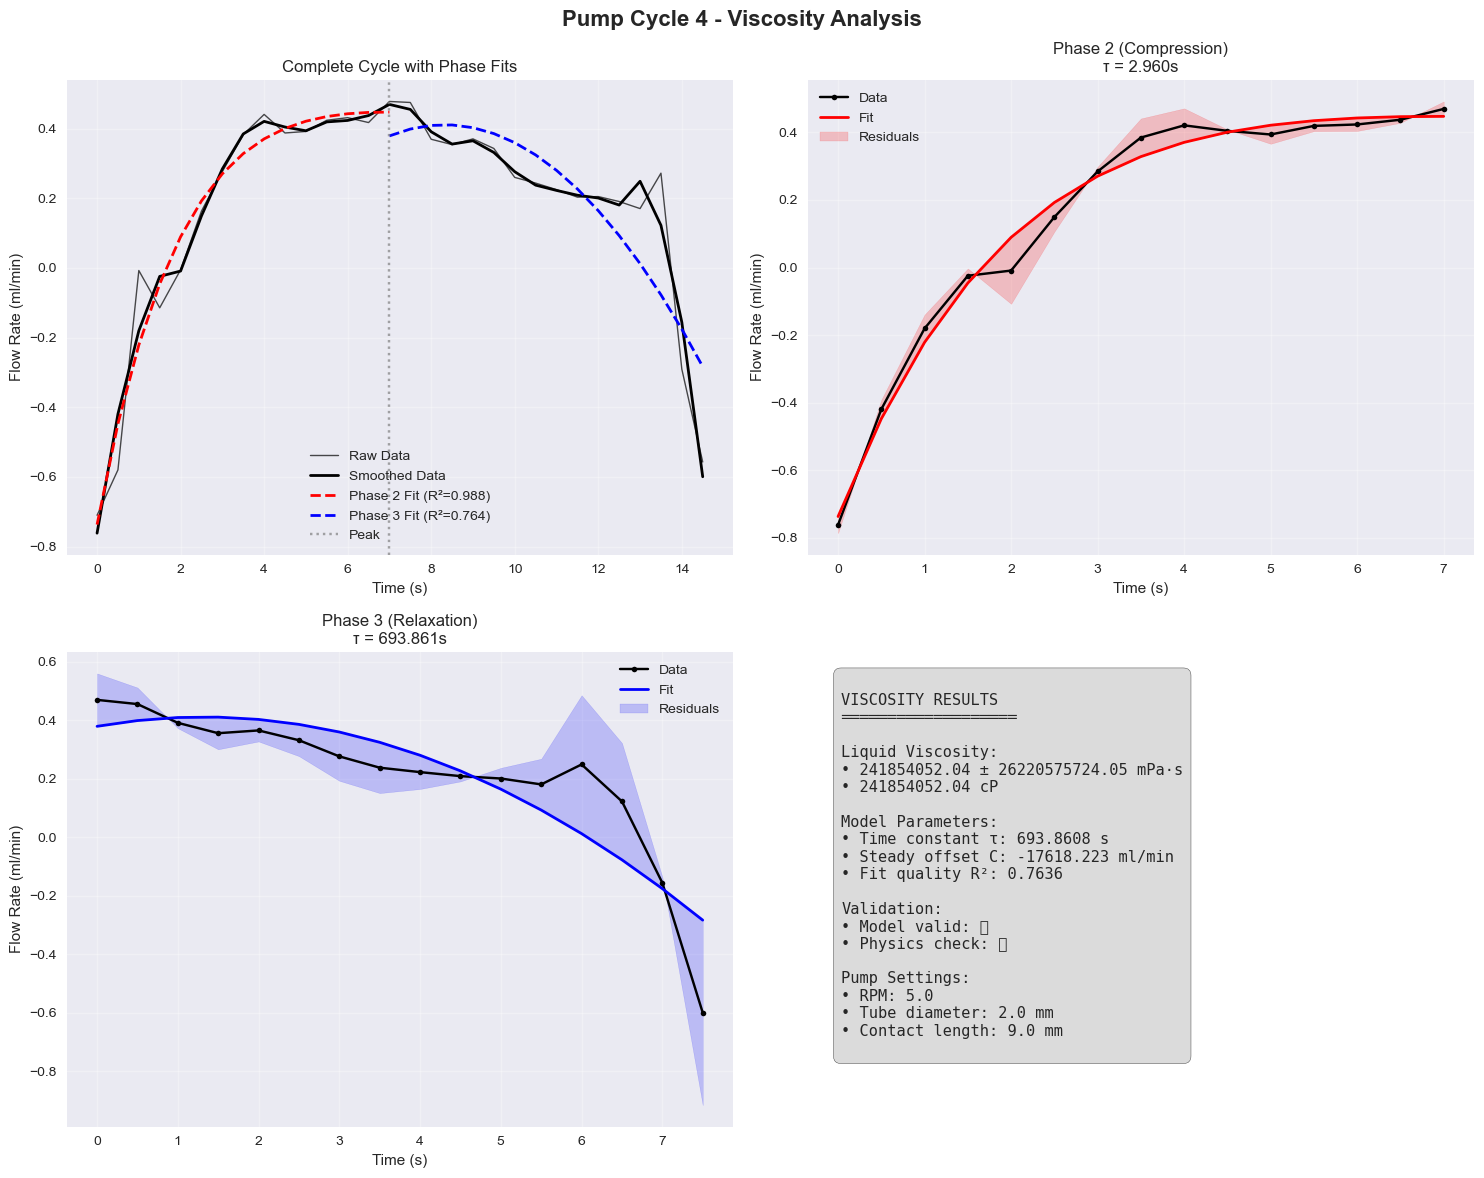



🔬 Analyzing Cycle 5
   Duration: 14.51s
   Data points: 30
   Flow range: -0.56 to 0.49 ml/min
🔄 Phase splitting:
   Peak at t = 7.00s (index 14)
   Phase 2 duration: 7.00s
   Phase 3 duration: 7.51s
✅ Phase 2 (Compression) fit complete:
   Model: generalized exponential
   R² = 0.9765, RMSE = 0.0497
   A = 5.2986 ± 22.4037
   B = 0.8232 ± 1.1305
   tau = 12.4126 ± 17.8888 s
   C = -5.8667 ± 22.3789
✅ Phase 3 (Relaxation) fit complete:
   Model: generalized exponential
   R² = 0.7285, RMSE = 0.1364
   A = 16517.3149 ± 5545455.2437
   B = 25.2399 ± 4212.3159
   tau = 655.8487 ± 110494.0754 s
   C = -16516.9337 ± 5545455.2479
🧮 Viscosity Calculation:
   Time constant τ = 655.8487 s
   Steady offset C = -16516.9337 ml/min
   Amplitude A = 16517.3149
   Internal area A_int = 3.14 mm²
   Geometric factor α = 2865 1/m
   Flow resistance Γ = 3303.386738

🎯 Viscosity Results:
   μ = 228585.321689 Pa·s
   μ = 228585321.689 mPa·s
   μ = 228585321.689 cP
   Uncertainty: ±38569708376.316 mPa·s
 

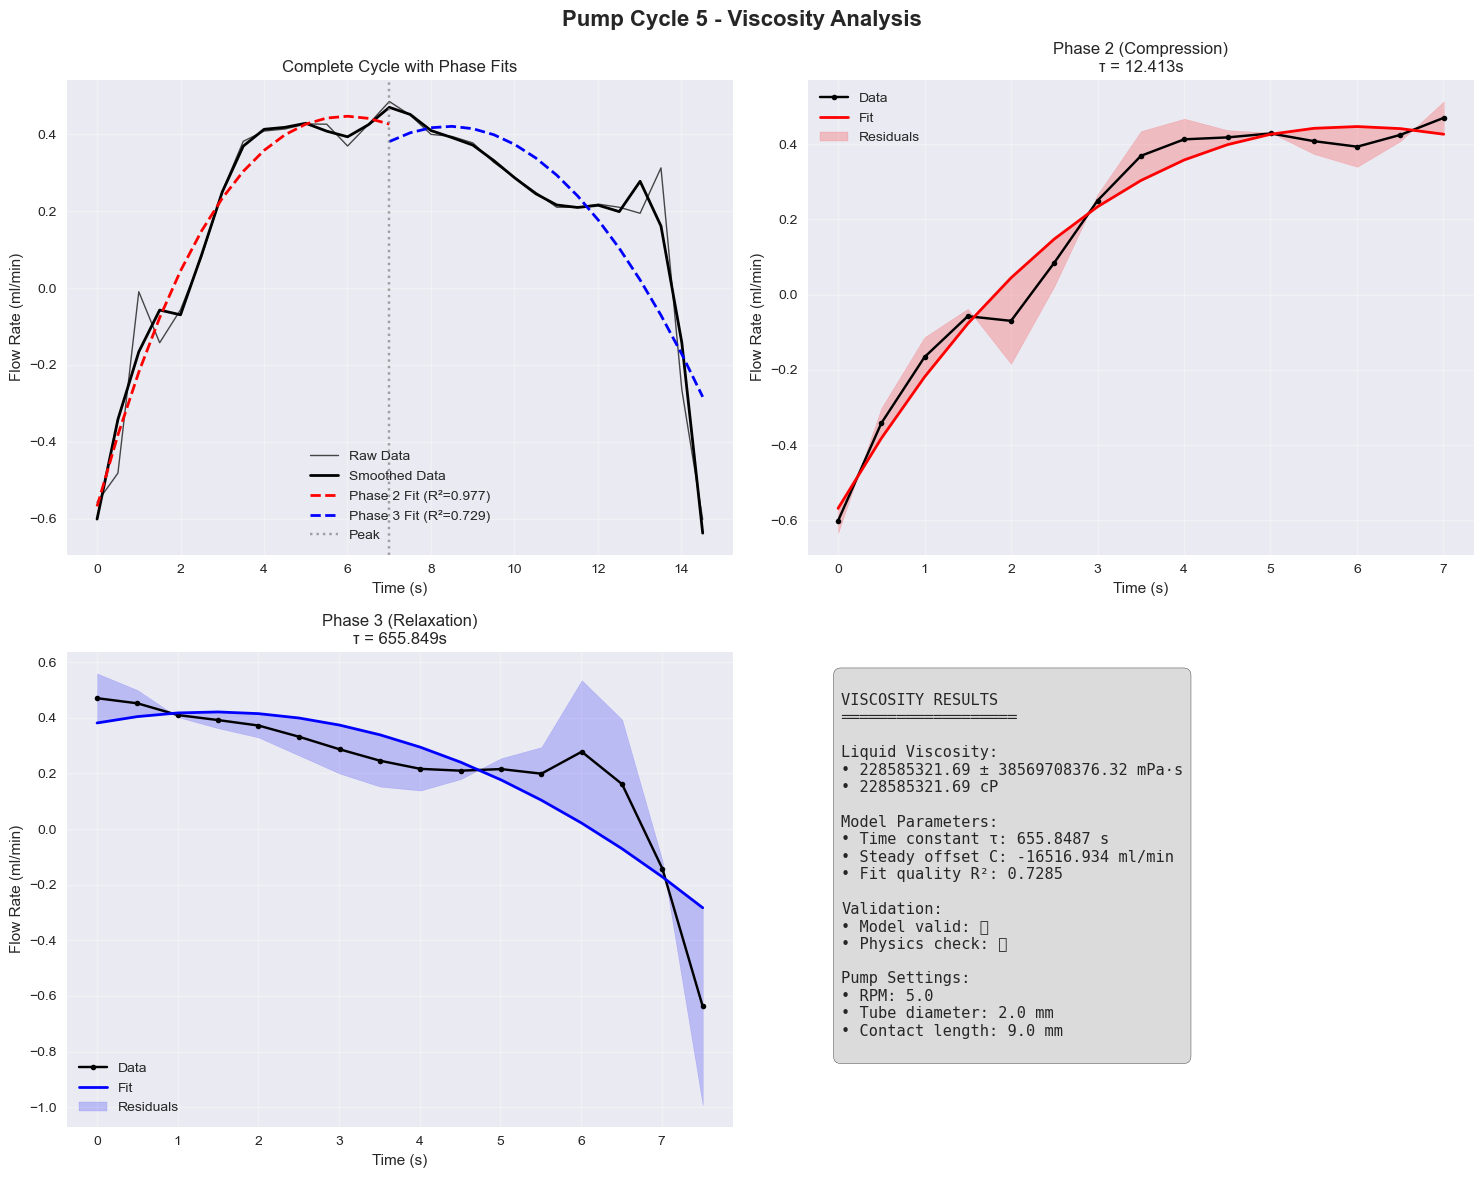



🔬 Analyzing Cycle 6
   Duration: 15.00s
   Data points: 31
   Flow range: -0.60 to 0.47 ml/min
🔄 Phase splitting:
   Peak at t = 6.50s (index 13)
   Phase 2 duration: 6.50s
   Phase 3 duration: 8.50s
✅ Phase 2 (Compression) fit complete:
   Model: generalized exponential
   R² = 0.9726, RMSE = 0.0560
   A = 0.8326 ± 9.1306
   B = 0.5217 ± 0.8869
   tau = 8.0862 ± 12.8444 s
   C = -1.4434 ± 9.1030
✅ Phase 3 (Relaxation) fit complete:
   Model: generalized exponential
   R² = 0.7759, RMSE = 0.1129
   A = 16469.1945 ± 3162820.9455
   B = 21.0494 ± 2012.6770
   tau = 783.8464 ± 75446.1060 s
   C = -16468.7946 ± 3162820.9334
🧮 Viscosity Calculation:
   Time constant τ = 783.8464 s
   Steady offset C = -16468.7946 ml/min
   Amplitude A = 16469.1945
   Internal area A_int = 3.14 mm²
   Geometric factor α = 2865 1/m
   Flow resistance Γ = 3293.758920

🎯 Viscosity Results:
   μ = 273264.945850 Pa·s
   μ = 273264945.850 mPa·s
   μ = 273264945.850 cP
   Uncertainty: ±26335659147.083 mPa·s
   R²

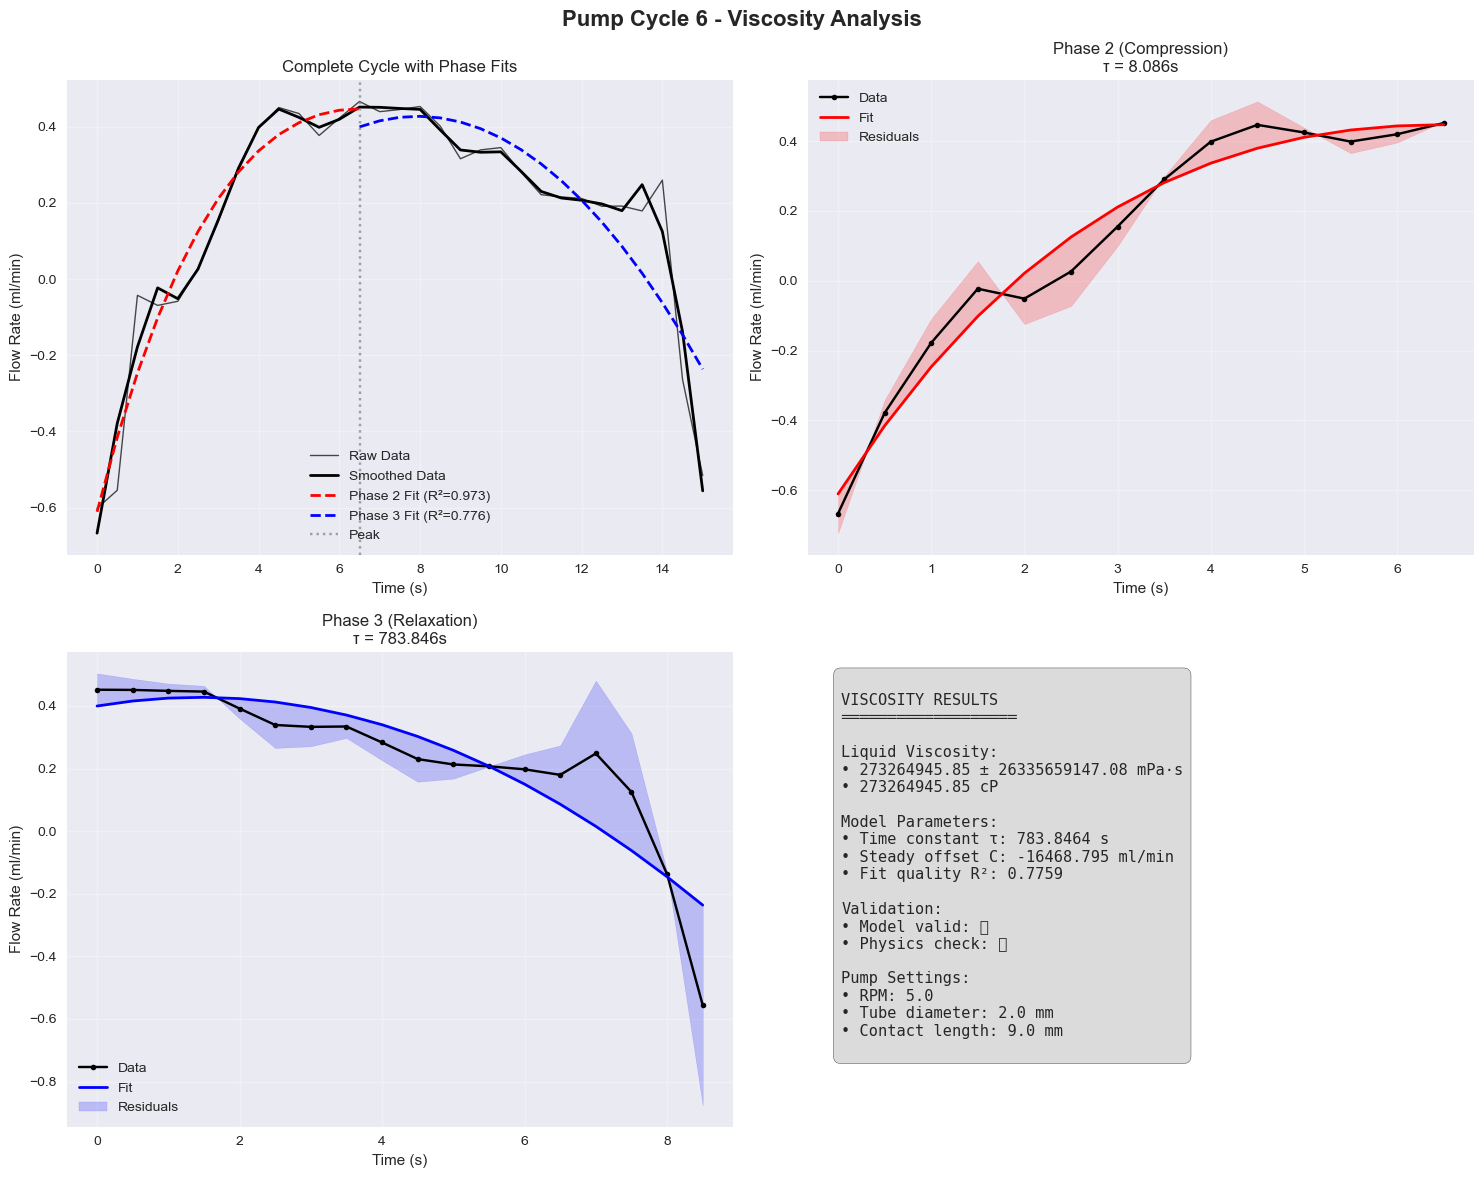


❌ No valid viscosity measurements obtained
Check data quality and model assumptions


In [23]:
# VISCOSITY ANALYSIS WORKFLOW
# ============================

# Step 1: Select sample and analyze all cycles
sample_name = 'water_b1_ml_min'  # Change this to analyze different samples

print(f"🔍 Analyzing sample: {sample_name}")
print("=" * 50)

# Get all cycles for the selected sample
all_cycles = get_cycle_data(sample_name, cycle_number=None)

if all_cycles:
    # Store results for all cycles
    cycle_results = []
    viscosity_measurements = []
    
    # Analyze each cycle individually
    for cycle in all_cycles:
        print(f"\n{'='*60}")
        result = analyze_cycle(cycle, pump_params, plot=True)
        cycle_results.append(result)
        
        # Collect successful viscosity measurements
        if result['viscosity_results'] and result['viscosity_results']['model_valid']:
            viscosity_measurements.append(result['viscosity_results']['viscosity_mPa_s'])
    
    # Statistical analysis of viscosity measurements
    if viscosity_measurements:
        viscosity_array = np.array(viscosity_measurements)
        mean_viscosity = np.mean(viscosity_array)
        std_viscosity = np.std(viscosity_array)
        cv = (std_viscosity / mean_viscosity) * 100  # Coefficient of variation
        
        print(f"\n🎯 FINAL VISCOSITY ANALYSIS")
        print(f"{'='*50}")
        print(f"Sample: {sample_name}")
        print(f"Valid measurements: {len(viscosity_measurements)}/{len(all_cycles)}")
        print(f"Mean viscosity: {mean_viscosity:.3f} ± {std_viscosity:.3f} mPa·s")
        print(f"Coefficient of variation: {cv:.1f}%")
        print(f"Range: {min(viscosity_measurements):.3f} - {max(viscosity_measurements):.3f} mPa·s")
        
        # Quality assessment
        if cv < 10:
            quality = "Excellent"
        elif cv < 20:
            quality = "Good" 
        else:
            quality = "Poor"
        print(f"Measurement quality: {quality}")
        
    else:
        print("\n❌ No valid viscosity measurements obtained")
        print("Check data quality and model assumptions")

else:
    print(f"\n❌ Failed to analyze sample {sample_name}")
    available_samples = [col for col in df.columns if 'ml_min' in col]
    print(f"Available samples: {available_samples}")

In [24]:
# COMPREHENSIVE VISCOSITY DATABASE
# =================================

def analyze_all_samples(df, pump_params, max_cycles_per_sample=5):
    """
    Analyze all available samples in the dataset for viscosity.
    
    Parameters:
    - df: DataFrame with experimental data
    - pump_params: pump physical parameters
    - max_cycles_per_sample: maximum number of cycles to analyze per sample
    
    Returns:
    - Dictionary with complete viscosity database
    """
    # Find all flow rate columns
    flow_columns = [col for col in df.columns if 'ml_min' in col]
    
    print(f"🧪 Found {len(flow_columns)} samples to analyze:")
    for i, col in enumerate(flow_columns, 1):
        print(f"   {i}. {col}")
    
    viscosity_database = {}
    
    for sample_name in flow_columns:
        print(f"\n{'='*70}")
        print(f"📊 ANALYZING SAMPLE: {sample_name}")
        print(f"{'='*70}")
        
        # Get cycles for this sample
        cycles = get_cycle_data(sample_name, cycle_number=None)
        
        if not cycles:
            viscosity_database[sample_name] = {
                'status': 'failed',
                'error': 'No cycles detected'
            }
            continue
        
        # Limit number of cycles to analyze
        cycles_to_analyze = cycles[:max_cycles_per_sample]
        
        sample_results = {
            'sample_name': sample_name,
            'total_cycles': len(cycles),
            'analyzed_cycles': len(cycles_to_analyze),
            'cycle_results': [],
            'viscosity_measurements': [],
            'status': 'analyzed'
        }
        
        # Analyze each cycle (without plots for efficiency)
        for i, cycle in enumerate(cycles_to_analyze):
            print(f"\n📈 Cycle {i+1}/{len(cycles_to_analyze)}")
            result = analyze_cycle(cycle, pump_params, plot=False)
            sample_results['cycle_results'].append(result)
            
            # Collect valid viscosity measurements
            if (result['viscosity_results'] and 
                result['viscosity_results']['model_valid'] and
                result['viscosity_results']['fit_quality'] > 0.7):
                viscosity_measurements.append(result['viscosity_results']['viscosity_mPa_s'])
        
        # Calculate statistics if we have measurements
        if sample_results['viscosity_measurements']:
            viscosity_array = np.array(sample_results['viscosity_measurements'])
            sample_results.update({
                'mean_viscosity': np.mean(viscosity_array),
                'std_viscosity': np.std(viscosity_array),
                'min_viscosity': np.min(viscosity_array),
                'max_viscosity': np.max(viscosity_array),
                'cv_percent': (np.std(viscosity_array) / np.mean(viscosity_array)) * 100,
                'valid_measurements': len(viscosity_array)
            })
        else:
            sample_results.update({
                'mean_viscosity': None,
                'std_viscosity': None,
                'min_viscosity': None,
                'max_viscosity': None,
                'cv_percent': None,
                'valid_measurements': 0,
                'error': 'No valid viscosity measurements'
            })
        
        viscosity_database[sample_name] = sample_results
        
        # Print sample summary
        if sample_results['valid_measurements'] > 0:
            print(f"\n✅ Sample Results:")
            print(f"   Mean viscosity: {sample_results['mean_viscosity']:.3f} ± {sample_results['std_viscosity']:.3f} mPa·s")
            print(f"   Coefficient of variation: {sample_results['cv_percent']:.1f}%")
            print(f"   Valid measurements: {sample_results['valid_measurements']}/{sample_results['analyzed_cycles']}")
        else:
            print(f"\n❌ No valid viscosity measurements for {sample_name}")
    
    return viscosity_database

# Create summary table function
def create_viscosity_summary_table(viscosity_database):
    """Create a formatted summary table of all viscosity measurements."""
    
    print(f"\n🏆 VISCOSITY MEASUREMENT SUMMARY")
    print(f"{'='*80}")
    print(f"{'Sample':<25} {'Viscosity (mPa·s)':<20} {'CV (%)':<8} {'Valid/Total':<12} {'Quality':<10}")
    print(f"{'-'*80}")
    
    for sample_name, results in viscosity_database.items():
        if results.get('valid_measurements', 0) > 0:
            viscosity_str = f"{results['mean_viscosity']:.2f} ± {results['std_viscosity']:.2f}"
            cv_str = f"{results['cv_percent']:.1f}"
            count_str = f"{results['valid_measurements']}/{results['analyzed_cycles']}"
            
            # Determine quality
            if results['cv_percent'] < 10:
                quality = "Excellent"
            elif results['cv_percent'] < 20:
                quality = "Good"
            else:
                quality = "Poor"
            
            print(f"{sample_name:<25} {viscosity_str:<20} {cv_str:<8} {count_str:<12} {quality:<10}")
        else:
            print(f"{sample_name:<25} {'Failed':<20} {'-':<8} {'0/0':<12} {'-':<10}")
    
    print(f"{'-'*80}")

# Display pump parameters reminder
print("🔧 Current Pump Parameters:")
for key, value in pump_params.items():
    if key == 'omega':
        rpm = value * 60 / (2 * np.pi)
        print(f"   {key}: {value:.4f} rad/s ({rpm:.1f} RPM)")
    elif 'e-' in str(value):
        print(f"   {key}: {value:.1e}")
    else:
        print(f"   {key}: {value}")
print()

🔧 Current Pump Parameters:
   omega: 0.5236 rad/s (5.0 RPM)
   D_axis: 0.03
   d_int: 0.002
   L_c: 0.009
   E: 1000000.0
   eta_tube: 1000000.0



In [25]:
# RUN COMPREHENSIVE ANALYSIS
# ==========================

# Analyze all samples in the dataset
print("🚀 Starting comprehensive viscosity analysis...")
print(f"Dataset: {DATA_FILE}")
print(f"Pump RPM: {pump_params['omega'] * 60 / (2 * np.pi):.1f}")
print(f"Tube diameter: {pump_params['d_int']*1000:.1f} mm")

# Run the analysis
viscosity_db = analyze_all_samples(df, pump_params, max_cycles_per_sample=3)

# Generate summary table
create_viscosity_summary_table(viscosity_db)

# Additional insights
valid_samples = [name for name, data in viscosity_db.items() 
                if data.get('valid_measurements', 0) > 0]

if valid_samples:
    all_viscosities = []
    for name in valid_samples:
        all_viscosities.extend([result['viscosity_results']['viscosity_mPa_s'] 
                               for result in viscosity_db[name]['cycle_results']
                               if result['viscosity_results'] and result['viscosity_results']['model_valid']])
    
    if all_viscosities:
        print(f"\n📈 DATASET STATISTICS")
        print(f"{'='*40}")
        print(f"Total valid measurements: {len(all_viscosities)}")
        print(f"Overall mean viscosity: {np.mean(all_viscosities):.3f} mPa·s")
        print(f"Overall std deviation: {np.std(all_viscosities):.3f} mPa·s")
        print(f"Range: {min(all_viscosities):.3f} - {max(all_viscosities):.3f} mPa·s")
        
        # Create histogram of all measurements
        plt.figure(figsize=(10, 6))
        plt.hist(all_viscosities, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        plt.xlabel('Viscosity (mPa·s)')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Viscosity Measurements\n(n={len(all_viscosities)} measurements from {len(valid_samples)} samples)')
        plt.grid(alpha=0.3)
        plt.axvline(np.mean(all_viscosities), color='red', linestyle='--', 
                   label=f'Mean: {np.mean(all_viscosities):.3f} mPa·s')
        plt.legend()
        plt.tight_layout()
        plt.show()

print(f"\n✅ Analysis complete! Results saved in 'viscosity_db' variable.")

🚀 Starting comprehensive viscosity analysis...
Dataset: Data/20251120_Silicon.csv
Pump RPM: 5.0
Tube diameter: 2.0 mm
🧪 Found 16 samples to analyze:
   1. water_b1_ml_min
   2. water_b2_ml_min
   3. water_b3_ml_min
   4. water_a1_ml_min
   5. si350_t1_ml_min
   6. si350_t2_ml_min
   7. si350_t3_ml_min
   8. si1000_t1_ml_min
   9. si1000_t2_ml_min
   10. si1000_t3_ml_min
   11. si5000_t1_ml_min
   12. si5000_t2_ml_min
   13. si5000_t3_ml_min
   14. si12500_t1_ml_min
   15. si12500_t2_ml_min
   16. si12500_t3_ml_min

📊 ANALYZING SAMPLE: water_b1_ml_min
✅ Detected 6 complete pump cycles
📊 Sample 'water_b1_ml_min' analysis:
   Total cycles detected: 6
   Cycle 1: 14.5s, amplitude: 1.15 ml/min
   Cycle 2: 14.5s, amplitude: 1.14 ml/min
   Cycle 3: 15.0s, amplitude: 1.16 ml/min
   Cycle 4: 14.5s, amplitude: 1.19 ml/min
   Cycle 5: 14.5s, amplitude: 1.09 ml/min
   Cycle 6: 15.0s, amplitude: 1.07 ml/min

📈 Cycle 1/3

🔬 Analyzing Cycle 1
   Duration: 14.51s
   Data points: 30
   Flow range: -0.6